# Shor with modern Qiskit


The original CERN notebook used Aqua's `Shor(N, a)` class. Qiskit Aqua has been removed, and current Qiskit no longer provides a one-line `Shor` algorithm class.

This migrated notebook preserves the original workflow: choose `N` and `a`, use a quantum order-finding circuit when `gcd(N, a) = 1`, and then recover factors classically with the same number-theoretic post-processing used by Shor's algorithm.

We begin, as in the original notebook, with $N=15$ and $a=2$.


In [5]:
%matplotlib inline

import numpy as np
from fractions import Fraction
from math import gcd, ceil, log2

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import QFTGate, UnitaryGate
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram


def modular_multiplication_gate(a, N, num_target):
    """Return the unitary |x> -> |a*x mod N> for x < N.

    Computational-basis states x >= N are left unchanged so that the
    operation is a permutation (and therefore unitary) on 2**num_target states.
    """
    dimension = 2 ** num_target
    matrix = np.zeros((dimension, dimension), dtype=complex)

    for x in range(dimension):
        y = (a * x) % N if x < N else x
        matrix[y, x] = 1.0

    gate = UnitaryGate(matrix)
    gate.name = f"M_{a}_mod_{N}"
    return gate


def order_finding_circuit(N, a, num_control=None):
    """Build the quantum phase-estimation circuit used for Shor order finding."""
    if gcd(a, N) != 1:
        raise ValueError("a and N must be coprime for quantum order finding.")

    num_target = ceil(log2(N))
    if num_control is None:
        num_control = 2 * num_target

    control = QuantumRegister(num_control, "control")
    target = QuantumRegister(num_target, "target")
    out = ClassicalRegister(num_control, "out")
    qc = QuantumCircuit(control, target, out)

    # The target register starts in |1>.
    qc.x(target[0])

    # Phase-estimation control register.
    qc.h(control)

    # Controlled powers U^(2^j), where U|x> = |a*x mod N>.
    for j in range(num_control):
        multiplier = pow(a, 2 ** j, N)
        U = modular_multiplication_gate(multiplier, N, num_target)
        controlled_U = U.control(1)
        qc.append(controlled_U, [control[j], *target])

    # Inverse quantum Fourier transform reveals the phase k/r.
    qc.append(QFTGate(num_control).inverse(), control)
    qc.measure(control, out)

    return qc


def recover_order_from_phase(phase, a, N):
    """Convert a measured phase into a validated candidate order r."""
    if phase == 0:
        return None

    denominator = Fraction(phase).limit_denominator(N).denominator

    # The measured fraction can reduce k/r, so its denominator may only
    # be a divisor of the true order. Test small multiples until a^r = 1 mod N.
    for multiple in range(1, N + 1):
        r = denominator * multiple
        if r > N:
            break
        if pow(a, r, N) == 1:
            return r

    return None


def shor_factor(N, a, shots=2048, seed=42):
    """Factor N using Shor's quantum order-finding step for a chosen a.

    The return value intentionally contains a `factors` field so the later
    CERN code can still use result['factors'].
    """
    common_factor = gcd(N, a)
    if common_factor > 1:
        return {
            "factors": [[common_factor, N // common_factor]],
            "order": None,
            "counts": None,
            "note": "A non-trivial factor was found classically by gcd(N, a).",
        }

    circuit = order_finding_circuit(N, a)
    sampler = StatevectorSampler(default_shots=shots, seed=seed)
    primitive_result = sampler.run([circuit]).result()
    counts = primitive_result[0].data.out.get_counts()

    num_control = circuit.cregs[0].size

    # Inspect the most probable measured phases first.
    for bitstring, _count in sorted(counts.items(), key=lambda item: item[1], reverse=True):
        phase = int(bitstring, 2) / (2 ** num_control)
        r = recover_order_from_phase(phase, a, N)

        if r is None or r % 2 != 0:
            continue

        x = pow(a, r // 2, N)
        if x in (1, N - 1):
            continue

        p = gcd(x - 1, N)
        q = gcd(x + 1, N)

        if 1 < p < N and 1 < q < N:
            return {
                "factors": [[p, q]],
                "order": r,
                "phase": phase,
                "measurement": bitstring,
                "counts": counts,
            }

    return {
        "factors": [],
        "order": None,
        "counts": counts,
        "note": "This choice/run did not yield non-trivial factors; Shor may need another a or another run.",
    }


N = 15
a = 2
factors = [[3, 5]]
order r = 4
measurement = 11000000


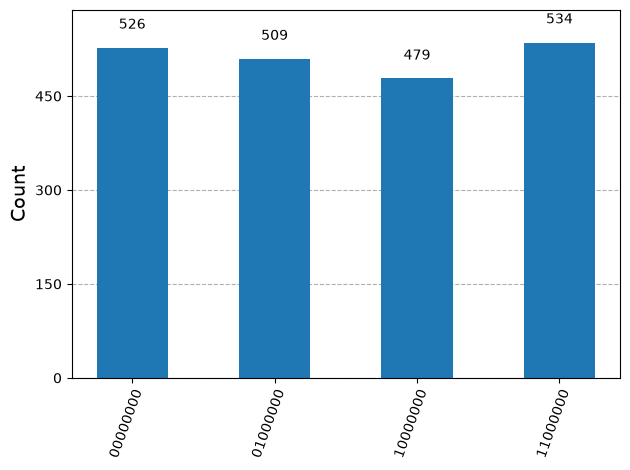

In [6]:
N = 15
a = 2

result = shor_factor(N=N, a=a)

print("N =", N)
print("a =", a)
print("factors =", result["factors"])
print("order r =", result.get("order"))
print("measurement =", result.get("measurement"))

if result.get("counts") is not None:
    plot_histogram(result["counts"])


Now we repeat the original experiment with $N=15$ and different values of $a$.

As in the Aqua notebook, we first compute $\gcd(N,a)$ classically. If it is greater than 1, we have already found a factor and do not need the quantum part. Only coprime values of $a$ are sent to the quantum order-finding routine.


In [10]:
N = 15
print("N =", N)

for a in range(2, N):
    print()
    print("a =", a)

    f = gcd(N, a)

    if f == 1:
        result = shor_factor(N, a)
        print("factors:", result["factors"])
        if result.get("order") is not None:
            print("estimated order r:", result["order"])
        elif result.get("note"):
            print(result["note"])
    else:
        print("A factor of", N, "is", f)


N = 15

a = 2
factors: [[3, 5]]
estimated order r: 4

a = 3
A factor of 15 is 3

a = 4
factors: [[3, 5]]
estimated order r: 2

a = 5
A factor of 15 is 5

a = 6
A factor of 15 is 3

a = 7
factors: [[3, 5]]
estimated order r: 4

a = 8
factors: [[3, 5]]
estimated order r: 4

a = 9
A factor of 15 is 3

a = 10
A factor of 15 is 5

a = 11
factors: [[5, 3]]
estimated order r: 2

a = 12
A factor of 15 is 3

a = 13
factors: [[3, 5]]
estimated order r: 4

a = 14
factors: []
This choice/run did not yield non-trivial factors; Shor may need another a or another run.
